# Q1: How has Zilretta's share shifted, and why did it fall?

**The question (business question 1):** how has visit share among the treatment categories shifted over the six years of data, is there a detectable turning point, and can an FDA event explain it?

**The answer, in one line:** Zilretta's share rose until early 2022 and has fallen since. The turn is statistically clear. No FDA brand-entry event explains it. The fall is a decline *inside* specialties, not a change in the mix of specialties.

This notebook shows the evidence. Everything here reads the published warehouse (`data/published/warehouse.db`) and uses the tested functions in `src/oa_market_intelligence/analysis/`. The methods were fixed in `docs/phase4_modeling_plan.md` before they were run on the real data (decisions DL-38, DL-44, DL-45).

**How to read the numbers.** *Share* means Zilretta's visits as a fraction of visits for Zilretta, generic corticosteroid injections and NSAIDs together. *pp* means percentage points: a move from 3.0% to 2.0% is 1 pp.

In [1]:
import sys
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.analysis.decomposition import (
    bootstrap_decomposition, decompose, decompose_chain, group_counts, year_windows)
from oa_market_intelligence.analysis.trend import (
    CATEGORIES, EVENTS, bootstrap_break_locations, break_tests, category_shares,
    events_overlapping, select_breaks)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 150)

engine = create_engine("sqlite:///../data/published/warehouse.db")
shares = category_shares(engine)
months = shares["month_id"].tolist()
print(f"{len(months)} months, {months[0]} to {months[-1]}")

72 months, 201908 to 202507


## 1. The three categories over time

Zilretta competes with a very large group of generic corticosteroid injections and with NSAIDs. In share terms Zilretta is small (between about 1.7% and 3.4%), and generic corticosteroids are about nine in every ten visits.

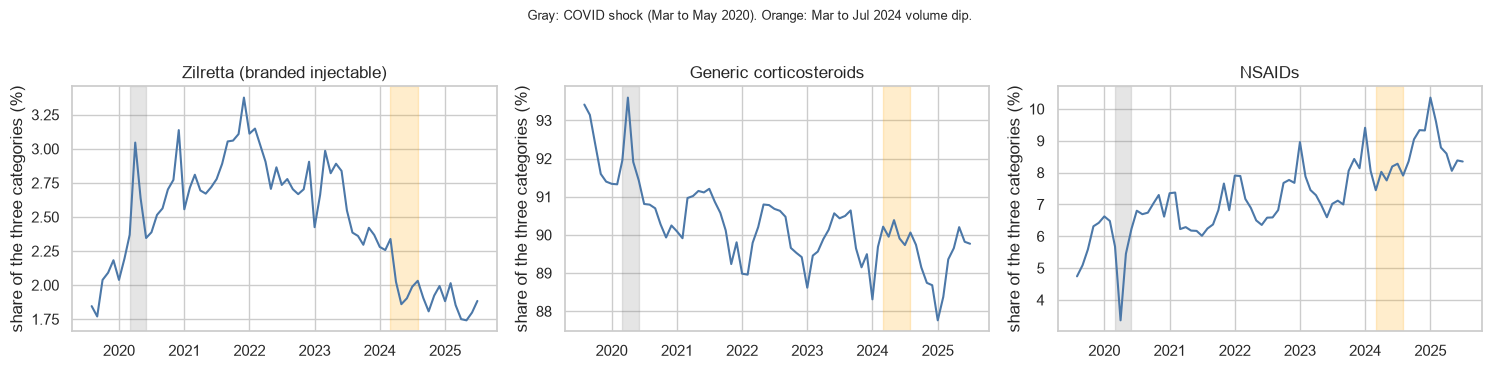

branded_injectable         2.47
generic_corticosteroid    90.27
nsaid_otc                  7.26


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
labels = {"branded_injectable": "Zilretta (branded injectable)",
          "generic_corticosteroid": "Generic corticosteroids",
          "nsaid_otc": "NSAIDs"}
for ax, cat in zip(axes, CATEGORIES):
    ax.plot(shares["month"], shares[cat] * 100, color="#4c78a8", lw=1.5)
    ax.axvspan("2020-03-01", "2020-05-31", color="gray", alpha=0.2)
    ax.axvspan("2024-03-01", "2024-07-31", color="orange", alpha=0.2)
    ax.set_title(labels[cat]); ax.set_ylabel("share of the three categories (%)")
fig.suptitle("Gray: COVID shock (Mar to May 2020). Orange: Mar to Jul 2024 volume dip.", y=1.02, fontsize=9)
plt.tight_layout(); plt.show()
print((shares[CATEGORIES].mean() * 100).round(2).to_string())

## 2. Where does the trend bend? A change-point test

**The method, in plain words.** Fit the series with one straight line, then with two straight lines joined at a "break" month, then with three. Ask whether the extra break improves the fit by more than random noise would.

**Why this needs care.** When the break month is unknown you can try every possible month, and the best of many tries always looks better than it should. The first version of this analysis used a standard fit-versus-complexity score (BIC) to decide how many breaks to keep. In testing it reported a break in about 73% of series that had none, so it was **replaced before it was ever run on the real data** (decision DL-44). The test used now keeps a break only if its improvement beats what noise produces in 95% of 1,000 simulations of the same search, with the noise resampled in blocks so month-to-month dependence is respected.

The next cell checks that claim: on 60 simulated series with no break at all, how often does the test report one? The target is about 5%. The noise below is month-to-month dependent (each month carries over half of the last month's noise), which is the hard case.

In [3]:
rng = np.random.default_rng(0)
false_positives = 0
for i in range(60):
    noise = np.zeros(72)
    e = rng.normal(0, 0.1, 72)
    for t in range(1, 72):
        noise[t] = 0.5 * noise[t - 1] + e[t]  # month-to-month dependent noise, no break
    series = 1.0 + 0.01 * np.arange(72) + noise
    false_positives += select_breaks(series, n_null=99, seed=i).n_breaks > 0
print(f"breaks reported in {false_positives} of 60 series that contain none ({false_positives/60:.0%}); target is about 5%")

breaks reported in 6 of 60 series that contain none (10%); target is about 5%


**Reading this.** The test reports a break in about 10% of break-free series when the noise is month-to-month dependent: roughly twice the 5% target, so the test is somewhat liberal in that hard case (the library's automated tests, which allow up to 20%, check independent and dependent noise). It does not change the Zilretta result, whose p-value is about 0.001, far below anything noise produces. It does mean a borderline break, such as the one found for generic corticosteroids at one block length (p = 0.027), should not be trusted, and the notebook does not.

## 3. The real series: the number of breaks and where they are

For each category: the p-value of each test (one break against none, then two against one), the number of breaks kept, the break month, and a 90% interval for the break month from a second block bootstrap. The whole analysis is repeated with bootstrap blocks of 3 and 12 months. A conclusion that changes with the block length would be called fragile.

In [4]:
rows = []
selected = {}
for cat in CATEGORIES:
    y = shares[cat].to_numpy() * 100
    for block in (6, 3, 12):
        tests = break_tests(y, n_null=1000, block_length=block, seed=0)
        fit = select_breaks(y, n_null=1000, block_length=block, seed=0)
        locs = bootstrap_break_locations(y, fit.n_breaks, n_boot=1000, block_length=block, seed=0)
        rows.append({
            "category": labels[cat], "block length": block,
            "p-values": [round(t["p_value"], 3) for t in tests],
            "breaks kept": fit.n_breaks,
            "break month": [months[b] for b in fit.breaks],
            "90% interval": [(months[lo], months[hi]) for lo, hi in locs],
        })
        if block == 6:
            selected[cat] = (fit, locs)
pd.DataFrame(rows).to_string(index=False)
print(pd.DataFrame(rows).to_string(index=False))

                     category  block length       p-values  breaks kept break month       90% interval
Zilretta (branded injectable)             6  [0.001, 0.28]            1    [202203] [(202105, 202207)]
Zilretta (branded injectable)             3 [0.001, 0.204]            1    [202203] [(202106, 202207)]
Zilretta (branded injectable)            12 [0.002, 0.319]            1    [202203] [(202104, 202207)]
      Generic corticosteroids             6        [0.091]            0          []                 []
      Generic corticosteroids             3         [0.07]            0          []                 []
      Generic corticosteroids            12 [0.027, 0.284]            1    [202103] [(202008, 202203)]
                       NSAIDs             6        [0.751]            0          []                 []
                       NSAIDs             3        [0.774]            0          []                 []
                       NSAIDs            12        [0.645]            0  

**Reading the table.** Zilretta has one break, at about March 2022, with a p-value near 0.001 at every block length. That is as small as 1,000 simulations can show. The 90% interval for the month is May 2021 to July 2022, so the date is known to within about half a year, not to the month. Generic corticosteroids have no reliable break (one block length finds a borderline one, which is why it is called fragile). NSAIDs have none.

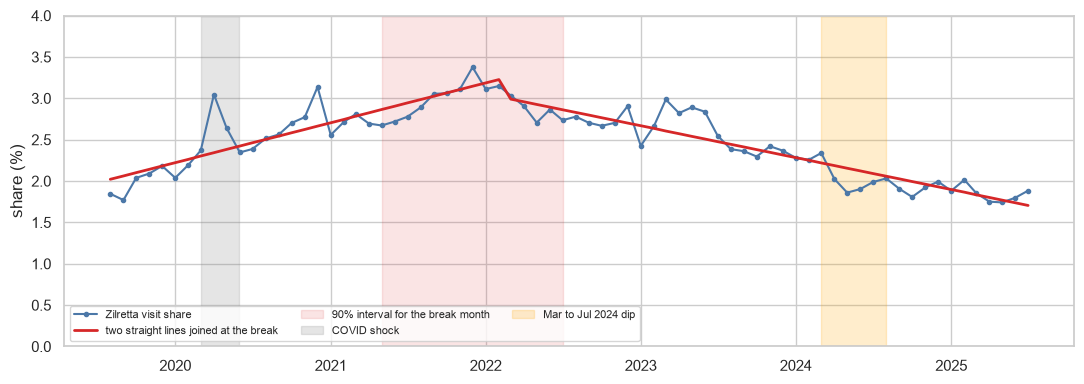

201908 to 202202: average 2.62%, trend +0.48 pp per year
202203 to 202507: average 2.35%, trend -0.39 pp per year
Break interval overlaps pre-specified events: none


In [5]:
fit, locs = selected["branded_injectable"]
y = shares["branded_injectable"].to_numpy() * 100
lo, hi = locs[0]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(shares["month"], y, "o-", ms=3, color="#4c78a8", label="Zilretta visit share")
ax.plot(shares["month"], fit.fitted, color="#d62728", lw=2, label="two straight lines joined at the break")
ax.axvspan(shares["month"][lo], shares["month"][hi], color="#d62728", alpha=0.12, label="90% interval for the break month")
ax.axvspan("2020-03-01", "2020-05-31", color="gray", alpha=0.2, label="COVID shock")
ax.axvspan("2024-03-01", "2024-07-31", color="orange", alpha=0.2, label="Mar to Jul 2024 dip")
ax.set_ylim(0, 4); ax.set_ylabel("share (%)"); ax.legend(fontsize=8, ncol=3, loc="lower left")
plt.tight_layout(); plt.show()
seg = [0, *fit.breaks, len(y)]
for a, b in zip(seg, seg[1:]):
    slope = np.polyfit(np.arange(a, b), y[a:b], 1)[0] * 12
    print(f"{months[a]} to {months[b-1]}: average {y[a:b].mean():.2f}%, trend {slope:+.2f} pp per year")
print("Break interval overlaps pre-specified events:", events_overlapping((months[lo], months[hi])) or "none")

**What this shows.** Before the break Zilretta's share rose about 0.5 pp a year; after it, it fell about 0.4 pp a year. The break interval overlaps neither pre-specified event (COVID, the 2024 dip): the turn is not one of those.

## 4. Can an FDA event explain it?

The assignment asks whether the turning point can be corroborated by FDA approval dates. The warehouse only held an approval date for Zilretta itself (October 2017, before our data starts in August 2019), because the pipeline looks up approvals for branded injectables only. On 7 October 2026 the approval dates of **every branded product in the share formula** (plus the opioid-tagged ones, to check one product) were looked up in the public openFDA Drugs@FDA API (decision DL-45). The snapshot is committed, so this cell does not call the internet.

In [6]:
fda = pd.read_csv("../data/reference/openfda_competitive_set_approvals_2026-10-07.csv", parse_dates=["earliest_orig"])
in_formula = fda[fda["treatment_category"].isin(["branded_injectable", "generic_corticosteroid", "nsaid_otc"])]
print(f"{len(fda)} products looked up; dates found for {fda['earliest_orig'].notna().sum()}")
print(f"In the share formula: {len(in_formula)} products, dates found for {in_formula['earliest_orig'].notna().sum()}")
dated = in_formula.dropna(subset=["earliest_orig"]).sort_values("earliest_orig")
print("Newest approvals in the share formula:")
print(dated.tail(5)[["product_name", "treatment_category", "earliest_orig"]].to_string(index=False))
window = fda[(fda["earliest_orig"] >= "2019-08-01") & (fda["earliest_orig"] <= "2025-07-31")]
print("\nApprovals inside the data window (Aug 2019 to Jul 2025):")
print(window[["product_name", "treatment_category", "earliest_orig"]].to_string(index=False))

70 products looked up; dates found for 33
In the share formula: 43 products, dates found for 19
Newest approvals in the share formula:
product_name     treatment_category earliest_orig
 A-METHAPRED generic_corticosteroid    1978-03-28
     DOLOBID              nsaid_otc    1982-04-19
      ZIPSOR              nsaid_otc    2009-06-16
    ZORVOLEX              nsaid_otc    2013-10-18
    ZILRETTA     branded_injectable    2017-10-06

Approvals inside the data window (Aug 2019 to Jul 2025):
product_name treatment_category earliest_orig
      ANJESO       opioid_other    2020-02-20


**What this shows.** No branded product in the share formula was approved inside our data window. The only approval in the window is Anjeso (February 2020), which is tagged as an opioid-category product, is outside the share formula, and has **2 visits in the whole dataset**. So a *brand-entry* FDA event does not explain the 2022 turn. This does not rule out new generic approvals, label changes or payer and formulary shifts, which an original-approval lookup cannot see. About 61% of visits belong to products with a date; 39% are unbranded generics that cannot be looked up by brand name.

## 5. Why did share fall: the mix of specialties, or Zilretta's share inside them?

Zilretta's share of the category total equals the sum, over specialties, of (the specialty's share of visits) × (Zilretta's share *within* that specialty). Any change in total share therefore splits exactly into:

- a **mix effect**: the weights moved (for example, more visits from physician assistants and fewer from orthopedic surgeons), and
- a **rate effect**: Zilretta's share within specialties moved.

The 72 months are exactly six 12-month windows (August to July). The first check is that the segment table reconciles to the monthly totals; the decomposition below is only trusted if it does.

In [7]:
gold = pd.read_sql(
    "SELECT month_id, branded_injectable_visits z, "
    "branded_injectable_visits+generic_corticosteroid_visits+nsaid_otc_visits t "
    "FROM gold_visit_share_monthly ORDER BY month_id", engine)
for by in ("specialty", "age_gender", "segment"):
    c = group_counts(engine, by=by)
    m = c.groupby("month_id")[["zilretta", "category"]].sum().reset_index().merge(gold, on="month_id")
    print(f"{by:10s} groups={c['group'].nunique():4d}  max difference in Zilretta visits {int((m.zilretta - m.z).abs().max())}, in category visits {int((m.category - m.t).abs().max())}")
windows = year_windows(gold["month_id"])
print("windows:", [(w[0], w[-1]) for w in windows])

specialty  groups=  50  max difference in Zilretta visits 0, in category visits 0


age_gender groups=  27  max difference in Zilretta visits 0, in category visits 0


segment    groups= 634  max difference in Zilretta visits 0, in category visits 0
windows: [(201908, 202007), (202008, 202107), (202108, 202207), (202208, 202307), (202308, 202407), (202408, 202507)]


comparison  share before (%)  share after (%)  change (pp)  mix effect (pp)  rate effect (pp)
    1 to 2             2.193            2.720        0.527            0.008             0.519
    2 to 3             2.720            2.990        0.270            0.029             0.241
    3 to 4             2.990            2.749       -0.241            0.012            -0.253
    4 to 5             2.749            2.222       -0.527           -0.001            -0.527
    5 to 6             2.222            1.877       -0.346            0.014            -0.359
    1 to 6             2.193            1.877       -0.317            0.082            -0.399


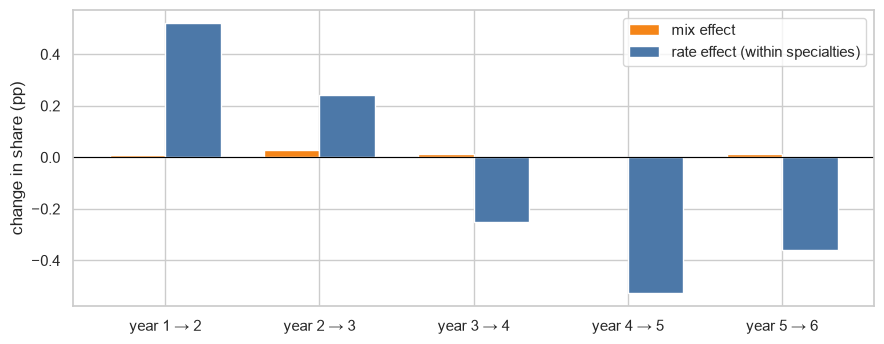

In [8]:
counts = group_counts(engine, by="specialty")
chain = decompose_chain(counts, windows)
show = chain.copy()
for c in ("share_a", "share_b", "total", "mix", "rate"):
    show[c] = (show[c] * 100).round(3)
show = show.rename(columns={"share_a": "share before (%)", "share_b": "share after (%)", "total": "change (pp)",
                            "mix": "mix effect (pp)", "rate": "rate effect (pp)"})
print(show.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
cons = chain.iloc[:5]
x = np.arange(len(cons))
ax.bar(x - 0.18, cons["mix"] * 100, 0.36, label="mix effect", color="#f58518")
ax.bar(x + 0.18, cons["rate"] * 100, 0.36, label="rate effect (within specialties)", color="#4c78a8")
ax.set_xticks(x); ax.set_xticklabels([f"year {c.replace(' to ', ' → ')}" for c in cons["comparison"]])
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("change in share (pp)"); ax.legend()
plt.tight_layout(); plt.show()

**What this shows.** In every year-to-year comparison the rate effect is the large one and the mix effect is close to zero. The total fall from the first year to the last is 0.32 pp, of which the rate effect is -0.40 pp and the mix effect +0.08 pp (the mix moved slightly in Zilretta's favour).

Next: the same split from the peak year (August 2021 to July 2022) to the latest year, with 90% intervals from resampling the months inside each window. **These two peak-year comparisons were chosen after the Step 2 break was seen, so they are labelled exploratory;** the year-by-year and first-to-last comparisons above were fixed in advance and tell the same story.

In [9]:
for label, (i, j) in {"first year to last year (fixed in advance)": (0, 5), "peak year to last year (exploratory)": (2, 5)}.items():
    b = bootstrap_decomposition(counts, windows[i], windows[j], n_boot=1000, seed=0)
    print(label)
    for k, name in (("total", "change in share"), ("mix", "mix effect"), ("rate", "rate effect")):
        v = b[k]
        print(f"   {name:16s} {v['estimate']*100:+.3f} pp   90% interval [{v['low']*100:+.3f}, {v['high']*100:+.3f}]")

first year to last year (fixed in advance)
   change in share  -0.317 pp   90% interval [-0.451, -0.188]
   mix effect       +0.082 pp   90% interval [+0.069, +0.099]
   rate effect      -0.399 pp   90% interval [-0.545, -0.258]


peak year to last year (exploratory)
   change in share  -1.114 pp   90% interval [-1.203, -1.017]
   mix effect       +0.082 pp   90% interval [+0.071, +0.093]
   rate effect      -1.196 pp   90% interval [-1.289, -1.093]


In [10]:
r = decompose(counts[counts.month_id.isin(windows[2])], counts[counts.month_id.isin(windows[5])])
t = r["by_group"].assign(abs_total=lambda d: d["total"].abs()).sort_values("abs_total", ascending=False).head(8)
table = pd.DataFrame({
    "specialty": t["group"],
    "share of visits, peak year (%)": (t["w_a"] * 100).round(1),
    "share of visits, latest year (%)": (t["w_b"] * 100).round(1),
    "Zilretta share, peak year (%)": (t["r_a"] * 100).round(2),
    "Zilretta share, latest year (%)": (t["r_b"] * 100).round(2),
    "mix effect (pp)": (t["mix"] * 100).round(3),
    "rate effect (pp)": (t["rate"] * 100).round(3),
})
print(f"Peak year to latest year: total change {r['total']*100:.3f} pp (mix {r['mix']*100:+.3f}, rate {r['rate']*100:+.3f})")
print(table.to_string(index=False))

Peak year to latest year: total change -1.114 pp (mix +0.082, rate -1.196)
           specialty  share of visits, peak year (%)  share of visits, latest year (%)  Zilretta share, peak year (%)  Zilretta share, latest year (%)  mix effect (pp)  rate effect (pp)
  ORTHOPEDIC SURGERY                            44.7                              35.4                           2.52                             1.53           -0.187            -0.396
OSTEOPATHIC MEDICINE                             8.1                               6.1                           3.70                             1.66           -0.054            -0.146
 PHYSICIAN ASSISTANT                            26.3                              37.8                           3.19                             1.88            0.292            -0.419
     SPORTS MEDICINE                             3.0                               2.2                           5.70                             2.52           -0.031            -0

**What this shows.** The mix really did move: Orthopedic Surgery fell from about 45% to 35% of visits and Physician Assistants rose from about 26% to 38%. But the two moves nearly cancel for Zilretta (-0.19 pp and +0.29 pp). What happened is a broad decline *inside* the big specialties: Zilretta's share fell in the four largest specialties (about 90% of visits) and in most smaller ones. It rose in two, Physical Medicine & Rehab and Family Practice.

## 6. Does it depend on the level of detail?

The split between mix and rate depends on how finely the groups are cut. The same year-by-year decomposition at three levels of detail (50 specialties, 27 age-and-gender groups, 634 full segments):

In [11]:
out = {}
for by in ("specialty", "age_gender", "segment"):
    c = decompose_chain(group_counts(engine, by=by), windows)
    out[by] = {"mix, first→last (pp)": round(c.iloc[-1]["mix"] * 100, 3), "rate, first→last (pp)": round(c.iloc[-1]["rate"] * 100, 3)}
print(pd.DataFrame(out).T.to_string())

            mix, first→last (pp)  rate, first→last (pp)
specialty                  0.082                 -0.399
age_gender                -0.004                 -0.313
segment                    0.085                 -0.402


**What this shows.** At every level of detail the rate effect is the main driver and the mix effect stays near zero. The finding does not depend on how finely the groups are cut.

## What this means, and what it does not

**Supported:**
- Zilretta's share rose until early 2022 and has fallen since; the turn is statistically clear and robust to the method settings (and, in notebook 07, to removing the known data problems).
- No branded product entered the market during our data window, and Zilretta's own approval predates it.
- The fall is Zilretta losing share inside the specialties that use it, not a shift in who is prescribing.

**Not supported:**
- *Why.* The data has no payer, geography, price, promotion or competitor-activity information. Describing where share fell is not the same as explaining it.
- *The exact date.* The 90% interval for the break is about 14 months wide.
- *Anything about RA.* About 1,283 RA visits in six years are too few for this analysis.

**Open lead, not a finding:** a search summary suggested Zilretta's Medicare outpatient pass-through payment status ended in March 2021, shortly before the break window. This could not be confirmed from a primary CMS source and is only a hypothesis to check (decision DL-57).